In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
df = pd.read_csv("Heart_disease_cleveland_new.csv")

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (303, 14)


In [5]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


C:\Users\Ayush\AppData\Local\Temp\ipykernel_18412\2653398799.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette=["#92fc8e","#ff8686"])


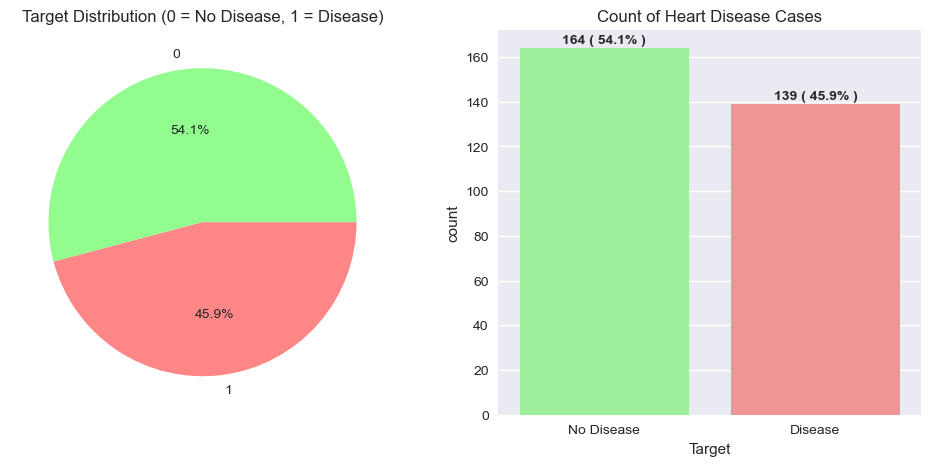

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=["#92fc8e","#ff8686"])
plt.title('Target Distribution (0 = No Disease, 1 = Disease)')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='target', palette=["#92fc8e","#ff8686"])
plt.title('Count of Heart Disease Cases')
plt.xlabel('Target')
plt.xticks([0, 1], ['No Disease', 'Disease'])
pct=['54.1%', '45.9%']
for i, v in enumerate(df['target'].value_counts()):
    plt.text(i, v + 2, str(v)+" ( " +pct[i] + " )", ha='center', fontweight='bold')
plt.show()

In [19]:
print(f"Disease prevalence: {df['target'].mean():.1%}")

Disease prevalence: 45.9%


In [55]:
import matplotlib.ticker as ticker

# Beautiful base style
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'figure.figsize': (16, 5.5 * 5),
    'axes.grid': True,
    'grid.color': '#d0d0d0',
    'grid.linestyle': '-',
    'grid.linewidth': 0.6,
})

# THIS FUNCTION WILL BE CALLED ON EVERY PLOT TO ADD PERFECT MINOR GRIDS
def add_fine_minor_grid(ax, x_step=1, y_step=5):
    """
    Adds:
      - Major bold grid every 10 (age), 50 (chol), etc.
      - Minor light grid every 1 (age), 5 or 10 (others)
    """
    # X-axis: every integer (age) or every 5/10 for others
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(x_step))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_step))
    
    ax.grid(which='minor', color="#e2e0e0", linewidth=0.7, alpha=1.0)
    ax.grid(which='major', color='#a0a0a0', linewidth=1.2, alpha=1.0)

def add_fine_minor_grid_y(ax, y_step=5):
    """
    Adds:
      - Major bold grid every 10 (age), 50 (chol), etc.
      - Minor light grid every 1 (age), 5 or 10 (others)
    """
    # X-axis: every integer (age) or every 5/10 for others
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_step))
    
    ax.grid(which='minor', color="#e2e0e0", linewidth=0.7, alpha=1.0)
    ax.grid(which='major', color='#a0a0a0', linewidth=1.2, alpha=1.0)

def add_fine_minor_grid_x(ax, x_step=1):
    """
    Adds:
      - Major bold grid every 10 (age), 50 (chol), etc.
      - Minor light grid every 1 (age), 5 or 10 (others)
    """
    # X-axis: every integer (age) or every 5/10 for others
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(x_step))
    
    ax.grid(which='minor', color="#e2e0e0", linewidth=0.7, alpha=1.0)
    ax.grid(which='major', color='#a0a0a0', linewidth=1.2, alpha=1.0)    


Summary statistics by target:


AttributeError: 'Axes' object has no attribute 'y_label'

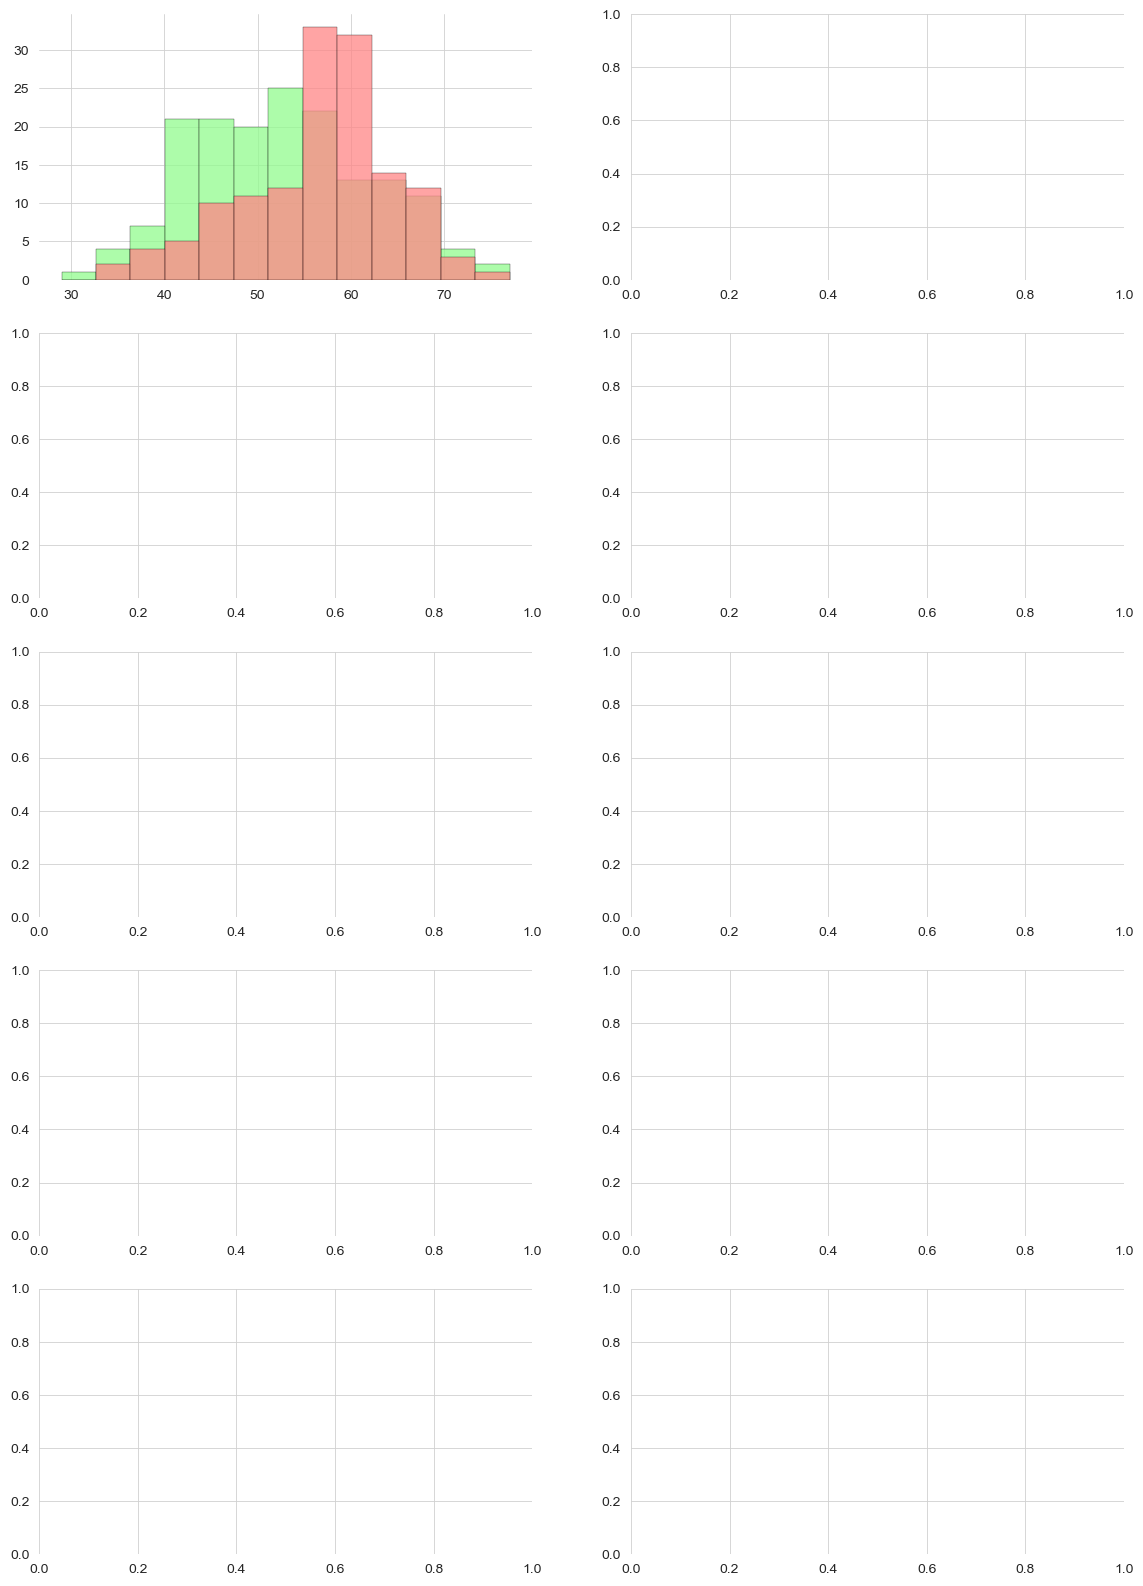

In [ ]:
df_viz = df.copy()

print("\nSummary statistics by target:")

# =============================================================================
# 5. UNIVARIATE DISTRIBUTIONS + BOXPLOTS BY TARGET
# =============================================================================

continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(len(continuous_features), 2, figsize=(14, 4*len(continuous_features)))
for i, col in enumerate(continuous_features):
    data_no  = df_viz[df_viz['target']==0][col]
    data_yes = df_viz[df_viz['target']==1][col]
    
    # LEFT: Histogram + KDE
    ax_hist = axes[i, 0]
    bins = np.histogram_bin_edges(pd.concat([data_no, data_yes]), bins='fd')
    ax_hist.hist(data_no,  bins=bins, alpha=0.75, label='No Disease',  color='#92fc8e', edgecolor='black')
    ax_hist.hist(data_yes, bins=bins, alpha=0.75, label='Disease',      color='#ff8686', edgecolor='black')
    ax_hist.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    sns.kdeplot(data_no,  ax=ax_hist, color='#92fc8e', linewidth=3)
    sns.kdeplot(data_yes, ax=ax_hist, color='#ff8686', linewidth=3)
    
    ax_hist.set_title(col.replace('_', ' ').title(), fontsize=16, pad=20)
    ax_hist.legend(fontsize=12)
    
    # APPLY FINE GRID — THIS IS THE MAGIC
    if col == 'age':
        add_fine_minor_grid(ax_hist, x_step=1, y_step=5)
    elif col == 'trestbps':
        add_fine_minor_grid(ax_hist, x_step=5, y_step=10)
    elif col == 'chol':
        add_fine_minor_grid(ax_hist, x_step=10, y_step=10)
    elif col == 'thalach':
        add_fine_minor_grid(ax_hist, x_step=5, y_step=10)
    elif col == 'oldpeak':
        add_fine_minor_grid(ax_hist, x_step=0.5, y_step=10)

    # RIGHT: Boxplot + points
    ax_box = axes[i, 1]
    sns.boxplot(data=df_viz, x='target', y=col, ax=ax_box,
                palette=["#92fc8e", "#ff8686"], width=0.5)
    
    ax_box.set_title(col.replace('_', ' ').title() + ' by Heart Disease', fontsize=16, pad=20)
    ax_box.set_xticklabels(['No Disease\n(y=0)', 'Disease\n(y=1)'], fontsize=12)

    if col == 'age':
        add_fine_minor_grid_y(ax_box, y_step=1)
    elif col == 'trestbps':
        add_fine_minor_grid_y(ax_box, y_step=5)
    elif col == 'chol':
        add_fine_minor_grid_y(ax_box, y_step=10)
    elif col == 'thalach':
        add_fine_minor_grid_y(ax_box, y_step=5)
    elif col == 'oldpeak':
        add_fine_minor_grid_y(ax_box, y_step=0.5)
    

plt.suptitle('Cleveland Heart Disease', 
             fontsize=22, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()